In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
path='/content/drive/MyDrive/Churn_Modelling.csv'
data=pd.read_csv(path)

In [ ]:
data.head()



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
display(data)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
##Divide the dataset into independent and dependent feature
X=data.iloc[:,3:13]
y=data.iloc[:,13]
print(X)
print(y)
X.head()
y.head()

      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0             619    France  Female   42       2       0.00              1   
1             608     Spain  Female   41       1   83807.86              1   
2             502    France  Female   42       8  159660.80              3   
3             699    France  Female   39       1       0.00              2   
4             850     Spain  Female   43       2  125510.82              1   
...           ...       ...     ...  ...     ...        ...            ...   
9995          771    France    Male   39       5       0.00              2   
9996          516    France    Male   35      10   57369.61              1   
9997          709    France  Female   36       7       0.00              1   
9998          772   Germany    Male   42       3   75075.31              2   
9999          792    France  Female   28       4  130142.79              1   

      HasCrCard  IsActiveMember  EstimatedSalary  
0           

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
##Feature Engineering
geography=pd.get_dummies(X["Geography"],drop_first=True)
geography.head()
gender=pd.get_dummies(X['Gender'],drop_first=True)
gender.head()

,Male
0,False
1,False
2,False
3,False
4,False


In [ ]:
#Concatenate these variables with dataframe
X=X.drop(['Geography','Gender'],axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [ ]:
X=pd.concat([X,geography,gender],axis=1)

In [ ]:
#Splitting the dataset into Traing seet and Test Set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=0
)


In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)#Calculates statistics (mean, std) from the data AND applies scaling
X_test=sc.transform(X_test)#Uses already calculated statistics to scale the data

In [ ]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [ ]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
X_test.shape

(2000, 11)

In [ ]:
## Part2 Now lets create ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU#activation
from tensorflow.keras.layers import Dropout

In [ ]:
##Lets initiaized ANN
classifier =Sequential()

In [ ]:
##Adding input layer
classifier.add(Dense(units=11,activation='relu'))

In [ ]:
#Adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.3))

In [ ]:
#Adding the second hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [ ]:
#Adding the output  layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [ ]:
classifier.compile(
    optimizer='adam',            # how to update weights
    loss='binary_crossentropy',  # how to measure error
    metrics=['accuracy']         # how to evaluate performance
)


In [ ]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(
    learning_rate=0.01)

In [ ]:
##Early stopping
import tensorflow as tf
tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=0,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [ ]:
model_history=classifier.fit(
    X_train,y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=1000,
    callbacks=[tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3)]
)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8055 - loss: 0.5558 - val_accuracy: 0.7955 - val_loss: 0.4728
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7942 - loss: 0.4667 - val_accuracy: 0.7955 - val_loss: 0.4487
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7994 - loss: 0.4420 - val_accuracy: 0.7955 - val_loss: 0.4403
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8006 - loss: 0.4347 - val_accuracy: 0.7955 - val_loss: 0.4344
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7911 - loss: 0.4291 - val_accuracy: 0.7955 - val_loss: 0.4312
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7940 - loss: 0.4333 - val_accuracy: 0.7955 - val_loss: 0.4226
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7964 - loss: 0.4119 - val_accuracy: 0.7955 - val_loss: 0.4152
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7991 - loss: 0.4132 - 

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

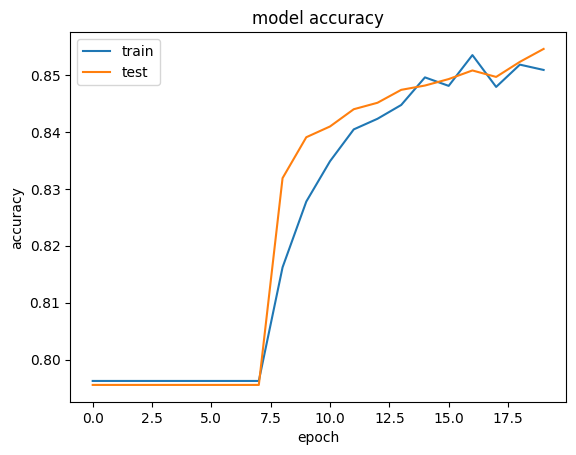

In [ ]:
#Summariaze the history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

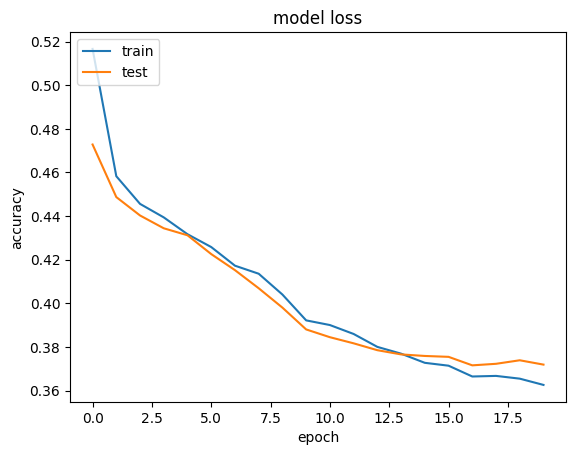

In [ ]:
#Summariaze the history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [ ]:
#Part3 making the prediction and evaluating the model

#Predicting the Test set results
y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
#Make confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1503,   92],
       [ 186,  219]])

In [ ]:
#Calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.861

In [ ]:
#Get weight
classifier.get_weights()

[array([[-0.31740066, -0.02340247,  0.11630835, -0.11206357,  0.26419637,
         -0.07600681,  0.21500306,  0.30281445,  0.2722183 , -0.01153365,
          0.03356775],
        [-0.72408086,  0.13939174,  0.49552068,  0.41349116, -0.77883345,
          0.28387022,  0.07936461, -0.5323245 , -0.6670296 ,  0.4190022 ,
         -0.65425783],
        [-0.14953516, -0.06752876,  0.11270908, -0.20762256, -0.08666891,
         -0.07832085,  0.09431646, -0.006042  ,  0.13410157,  0.26039845,
         -0.08555515],
        [ 0.21200089,  0.25123233, -0.10520057,  0.3155028 ,  0.27174333,
         -0.36920756,  0.15472655, -0.34204426, -0.21738356, -0.04561929,
         -0.15145454],
        [-0.02491228,  1.1200702 ,  0.45917252, -0.02352492,  0.19430085,
         -1.1551526 ,  0.47027284,  0.26404575,  0.16626033, -0.06504465,
          0.58717906],
        [ 0.18424273,  0.06534354,  0.29816747, -0.16695935,  0.32981282,
          0.13197362,  0.13953592, -0.2569357 ,  0.01116403,  0.2106583